# Week 3 - Part D: the clinical review figure

10,000 patient vital-sign records have to be checked before a safety review. The plan:

1. **Look before plotting.** Run the four inspection commands from the brief and read them.
2. **Clean, and write every rule down.** Each fix goes into `LOG` with the rule, the count, and (where it matters) what the mean moved from and to. This log is what Part E item 3 is built from.
3. **Build one 2x2 figure:** a distribution, a box plot across wards, a scatter of the one pair worth plotting, and a correlation heatmap done to the Lecture 6 rules.
4. **Export at 300 dpi**, plus an appendix version with the heart-rate faults left in, so nobody can say I hid them.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Works both as a notebook (opened from week3/) and as a script (week3/submission/x.py)
try:
    ROOT = Path(__file__).resolve().parents[1]
    IN_NOTEBOOK = False
except NameError:
    ROOT = Path.cwd()
    IN_NOTEBOOK = True
sys.path.insert(0, str(ROOT))

import vizlib
from vizlib import PALETTE, MARKERS, save_fig, style_defaults

DATA = ROOT / "data"
CHARTS = ROOT / "charts"
SUB = ROOT / "submission"
CHARTS.mkdir(exist_ok=True)
SUB.mkdir(exist_ok=True)

style_defaults()                      # house rcParams, set once
BLUE, ORANGE, GREEN = PALETTE["series"]
PINK = PALETTE["series_4th"]
GREY = PALETTE["muted"]
INK = PALETTE["ink"]
INK_SOFT = PALETTE["ink_soft"]
SRC = "Synthetic data generated for CDB601220 (Week 3)."
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore", category=FutureWarning)


def finish(fig, name, note, folder=None):
    """Save FIRST (300 dpi, source note), then show. Never the other way round."""
    path = save_fig(fig, (folder or CHARTS) / f"{name}.png", note)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)
    print("saved ->", Path(path).relative_to(ROOT))
    return path


## Step 0 - look at the data first

In [2]:
raw = pd.read_csv(DATA / "vitals_10k.csv")
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      10000 non-null  str    
 1   admit_date      10000 non-null  str    
 2   ward            10000 non-null  str    
 3   age             10000 non-null  int64  
 4   sex             10000 non-null  str    
 5   systolic        10000 non-null  int64  
 6   diastolic       10000 non-null  int64  
 7   map_mmhg        10000 non-null  float64
 8   heart_rate      10000 non-null  int64  
 9   spo2            10000 non-null  int64  
 10  bmi             10000 non-null  float64
 11  chol_mmol_l     10000 non-null  float64
 12  glucose_mmol_l  10000 non-null  float64
 13  los_days        10000 non-null  float64
 14  readmitted_30d  10000 non-null  int64  
 15  risk_score      10000 non-null  float64
dtypes: float64(6), int64(6), str(4)
memory usage: 1.2 MB


In [3]:
print(raw.describe().T.round(2))

                  count    mean     std   min     25%     50%     75%     max
age             10000.0   58.11   16.64  18.0   47.00   58.00   69.00   97.00
systolic        10000.0  137.66   22.60  92.0  119.00  128.00  160.00  199.00
diastolic       10000.0   79.63   13.13  45.0   69.00   78.00   90.00  125.00
map_mmhg        10000.0   98.97   15.83  65.3   85.70   94.30  113.70  149.70
heart_rate      10000.0   78.83   20.56   0.0   69.00   78.00   87.00  415.00
spo2            10000.0   96.72    2.24  81.0   96.00   97.00   98.00  100.00
bmi             10000.0   66.18  191.00   0.0   24.00   27.60   31.20  999.00
chol_mmol_l     10000.0    4.82    1.01   2.1    4.14    4.82    5.51    8.79
glucose_mmol_l  10000.0    6.55    1.15   5.1    5.70    6.30    7.10   13.90
los_days        10000.0    2.31    8.92   0.0    0.61    1.38    2.57  273.65
readmitted_30d  10000.0    0.04    0.20   0.0    0.00    0.00    0.00    1.00
risk_score      10000.0    1.12    1.10   0.0    0.31    0.96   

In [4]:
print(raw.ward.value_counts())
print()
print(raw.admit_date.head(20).tolist())

ward
General Medicine    1356
general medicine    1353
Gen Medicine        1309
CARDIOLOGY           914
cardio               886
Cardiology           882
Day Surgery          749
Day-Surgery          730
Intensive Care       486
ICU                  480
 I.C.U               442
icu                  413
Name: count, dtype: int64

['2026-01-19', '08-Mar-2026', '2026-02-26', '27/02/2026', '09/01/2026', '01-Apr-2026', '17-Apr-2026', '24-Mar-2026', '14-Apr-2026', '02-Jan-2026', '10/03/2026', '10/02/2026', '12-Apr-2026', '29/03/2026', '17-Apr-2026', '12/02/2026', '2026-03-28', '2026-02-03', '11-Apr-2026', '08/01/2026']


In [5]:
# A few extra checks the four commands do not cover
print("duplicate patient_id:", raw.patient_id.duplicated().sum(),
      "| fully duplicated rows (ignoring id):", raw.drop(columns="patient_id").duplicated().sum())
print("blank cells:", int(raw.isna().sum().sum()))
print("diastolic >= systolic:", (raw.diastolic >= raw.systolic).sum())
print("map_mmhg == (sys + 2*dia)/3 :", np.allclose(raw.map_mmhg, (raw.systolic + 2 * raw.diastolic) / 3, atol=0.06))
print()
for col in ["heart_rate", "bmi", "spo2", "los_days", "age", "chol_mmol_l", "risk_score"]:
    vc = raw[col].value_counts().sort_index()
    print(f"{col:15s} lowest values {dict(list(vc.head(3).items()))}   highest {dict(list(vc.tail(3).items()))}")

duplicate patient_id: 0 | fully duplicated rows (ignoring id): 0
blank cells: 0
diastolic >= systolic: 0
map_mmhg == (sys + 2*dia)/3 : True

heart_rate      lowest values {0: 8, 38: 15, 39: 4}   highest {406: 1, 412: 1, 415: 1}
bmi             lowest values {0.0: 84, 14.0: 44, 14.1: 3}   highest {44.8: 1, 46.0: 1, 999.0: 402}
spo2            lowest values {81: 1, 82: 1, 83: 3}   highest {98: 2256, 99: 1839, 100: 304}
los_days        lowest values {0.0: 2, 0.01: 10, 0.02: 14}   highest {242.26: 1, 251.52: 1, 273.65: 1}
age             lowest values {18: 90, 19: 22, 20: 19}   highest {95: 17, 96: 21, 97: 133}
chol_mmol_l     lowest values {2.1: 47, 2.11: 1, 2.13: 1}   highest {8.31: 1, 8.52: 1, 8.79: 1}
risk_score      lowest values {0.0: 2008, 0.004: 1, 0.0041: 1}   highest {7.9208: 1, 8.0: 2, 9.0: 2}


**What I found** (nothing in the file announces any of these):

| # | Problem | How I saw it |
|---|---|---|
| 1 | `ward` has **12 spellings for 4 wards**, including a leading space in `" I.C.U"` | `value_counts()` |
| 2 | `admit_date` is in **three formats** (`2026-01-19`, `08-Mar-2026`, `27/02/2026`), and the slash one is ambiguous | `head(20)` |
| 3 | `bmi` uses **0 and 999 as "missing"** - that is why the mean BMI is 66 | `describe()` max = 999, min = 0 |
| 4 | `heart_rate` has **device faults**: zeros and readings of 331-415 bpm | `describe()` max = 415 |
| 5 | `los_days` has a cluster of **139-274 day stays** with nothing between 30 and 100 days | `describe()` max = 273.65 |
| 6 | `map_mmhg` is **derived** from systolic and diastolic, so its correlation with them is arithmetic | data dictionary + the `allclose` check |
| 7 | `risk_score` is a **ratio** (events / days), so its mean is not the overall rate | data dictionary |
| 8 | `age` is **piled up at 18 and 97** (90 and 133 patients vs about 20 at neighbouring ages) - the ends were clipped | `value_counts()` |
| 9 | `bmi` piles at **14.0** and `chol_mmol_l` at **2.10**, again a clipped floor; `spo2` sits on its ceiling of 100 | `value_counts()` |

No duplicates, no blank cells, and no diastolic above systolic, so those are fine.

## Step 1 - clean it, and log every rule

In [6]:
LOG = {}
df = raw.copy()
LOG["rows loaded"] = f"{len(df):,}"

# 1. ward: strip + lower, then map every spelling onto one of four names
WARD_MAP = {
    "general medicine": "General Medicine", "gen medicine": "General Medicine",
    "cardiology": "Cardiology", "cardio": "Cardiology",
    "day surgery": "Day Surgery", "day-surgery": "Day Surgery",
    "intensive care": "ICU", "icu": "ICU", "i.c.u": "ICU",
}
df["ward_clean"] = df.ward.str.strip().str.lower().map(WARD_MAP)
assert df.ward_clean.nunique() == 4 and df.ward_clean.isna().sum() == 0
LOG["ward spellings conformed"] = (f"{df.ward.nunique()} spellings -> 4 wards (strip, lower, map); 0 rows lost")
print(df.groupby("ward_clean").ward.unique())
print(df.ward_clean.value_counts())

ward_clean
Cardiology                           [CARDIOLOGY, Cardiology, cardio]
Day Surgery                                [Day Surgery, Day-Surgery]
General Medicine    [General Medicine, general medicine, Gen Medic...
ICU                               [icu, ICU,  I.C.U , Intensive Care]
Name: ward, dtype: object
ward_clean
General Medicine    4018
Cardiology          2682
ICU                 1821
Day Surgery         1479
Name: count, dtype: int64


In [7]:
# 2. admit_date: parse each format explicitly. Never let pandas guess day vs month.
iso = pd.to_datetime(df.admit_date, format="%Y-%m-%d", errors="coerce")
mon = pd.to_datetime(df.admit_date, format="%d-%b-%Y", errors="coerce")
dmy = pd.to_datetime(df.admit_date, format="%d/%m/%Y", errors="coerce")
df["admit_dt"] = iso.fillna(mon).fillna(dmy)

slash = df.admit_date[df.admit_date.str.contains("/")].str.split("/", expand=True).astype(int)
print(f"ISO: {iso.notna().sum()}, dd-Mon-yyyy: {mon.notna().sum()}, dd/mm/yyyy: {dmy.notna().sum()}, unparsed: {df.admit_dt.isna().sum()}")
print(f"slash dates with first part > 12: {(slash[0] > 12).sum()}, with second part > 12: {(slash[1] > 12).sum()}  -> day comes first")
wrong = pd.to_datetime(df.admit_date, format="%m/%d/%Y", errors="coerce").notna().sum()
print(f"if I had read them as mm/dd, {wrong} dates would have parsed silently to the wrong day")
print("range:", df.admit_dt.min().date(), "to", df.admit_dt.max().date())
assert df.admit_dt.isna().sum() == 0
LOG["dates parsed"] = (f"3 formats parsed separately (ISO {iso.notna().sum()}, dd-Mon {mon.notna().sum()}, dd/mm {dmy.notna().sum()}); "
                       f"slash = day-first because {(slash[0] > 12).sum()} have day > 12; 0 unparsed")

ISO: 3382, dd-Mon-yyyy: 3365, dd/mm/yyyy: 3253, unparsed: 0
slash dates with first part > 12: 1933, with second part > 12: 0  -> day comes first
if I had read them as mm/dd, 1320 dates would have parsed silently to the wrong day
range: 2026-01-01 to 2026-04-30


In [8]:
# 3. bmi sentinels 0 and 999 -> missing
bmi_before = df.bmi.mean()
sent = df.bmi.isin([0, 999])
df.loc[sent, "bmi"] = np.nan
LOG["bmi sentinels removed"] = (f"bmi == 0 ({(raw.bmi == 0).sum()}) or 999 ({(raw.bmi == 999).sum()}) -> NaN, n = {sent.sum()}; "
                                f"mean {bmi_before:.2f} -> {df.bmi.mean():.2f} kg/m2")
print(LOG["bmi sentinels removed"])

bmi == 0 (84) or 999 (402) -> NaN, n = 486; mean 66.18 -> 27.35 kg/m2


In [9]:
# 4. heart_rate device faults. Rule: keep 30-250 bpm. 0 bpm is a disconnected probe,
#    >250 is not survivable at rest. This is the ethics item: removed AND reported.
HR_LO, HR_HI = 30, 250
hr_fault = (df.heart_rate < HR_LO) | (df.heart_rate > HR_HI)
hr_before = df.heart_rate.mean()
df["heart_rate_raw"] = df.heart_rate
df.loc[hr_fault, "heart_rate"] = np.nan
print("faulty readings:", sorted(int(v) for v in raw.heart_rate[hr_fault].unique()))
LOG["heart-rate device faults removed"] = (f"heart_rate < {HR_LO} ({(raw.heart_rate < HR_LO).sum()}, all 0 bpm) or > {HR_HI} "
                                           f"({(raw.heart_rate > HR_HI).sum()}, 331-415 bpm) -> NaN, n = {hr_fault.sum()}; "
                                           f"mean {hr_before:.2f} -> {df.heart_rate.mean():.2f} bpm")
print(LOG["heart-rate device faults removed"])
print("largest genuine reading kept:", df.heart_rate.max(), "bpm")

faulty readings: [0, 331, 333, 334, 335, 338, 340, 343, 347, 353, 355, 361, 366, 368, 374, 380, 387, 388, 396, 401, 402, 405, 406, 412, 415]
heart_rate < 30 (8, all 0 bpm) or > 250 (29, 331-415 bpm) -> NaN, n = 37; mean 78.83 -> 78.05 bpm
largest genuine reading kept: 135.0 bpm


In [10]:
# 5. los_days: a separate cluster of 139-274 day stays, with an empty gap from 30 to 100 days.
print(np.histogram(raw.los_days, bins=[0, 10, 30, 100, 300])[0], "<- stays in [0-10, 10-30, 30-100, 100-300] days")
long_ = df.los_days > 100
print("as hours / 24 these would be", (df.los_days[long_] / 24).round(1).min(), "to", (df.los_days[long_] / 24).round(1).max(), "days")
print(df.loc[long_, "ward_clean"].value_counts().to_dict())
los_before = df.los_days.mean()
df.loc[long_, "los_days"] = np.nan
LOG["implausible stays removed"] = (f"los_days > 100 -> NaN, n = {long_.sum()} (139.8-273.7 'days', likely hours keyed as days, "
                                    f"incl. {raw.loc[long_, 'ward'].str.lower().str.contains('day').sum()} in Day Surgery); "
                                    f"mean {los_before:.2f} -> {df.los_days.mean():.2f} days, median unchanged at {df.los_days.median():.2f}")
print(LOG["implausible stays removed"])

[9889   93    0   18] <- stays in [0-10, 10-30, 30-100, 100-300] days
as hours / 24 these would be 5.8 to 11.4 days
{'Day Surgery': 6, 'General Medicine': 6, 'ICU': 3, 'Cardiology': 3}
los_days > 100 -> NaN, n = 18 (139.8-273.7 'days', likely hours keyed as days, incl. 6 in Day Surgery); mean 2.31 -> 1.95 days, median unchanged at 1.38


In [11]:
# 6. map_mmhg is derived; 7. risk_score is a ratio. Neither goes in the heatmap.
LOG["derived column excluded"] = "map_mmhg = (sys + 2 x dia)/3 -> left out of the heatmap (its r with sys/dia is arithmetic)"

events = (df.risk_score * raw.los_days).round()
pooled_rate = events.sum() / raw.los_days.sum()
LOG["ratio column not averaged"] = (f"risk_score is events/day: mean of ratios {raw.risk_score.mean():.2f} vs pooled rate "
                                    f"{pooled_rate:.2f} events/day -> not averaged, not in heatmap")
print(LOG["ratio column not averaged"])

# 8 & 9. clipped ends: kept, but flagged, because the values are real patients at a capped value
LOG["clipped values flagged (kept)"] = (f"age = 18 ({(df.age == 18).sum()}) and 97 ({(df.age == 97).sum()}); bmi = 14.0 ({(df.bmi == 14.0).sum()}); "
                                        f"chol = 2.10 ({(df.chol_mmol_l == 2.10).sum()}); spo2 = 100 ({(df.spo2 == 100).sum()}, physical ceiling)")
LOG["duplicates / blanks"] = "0 duplicate ids, 0 blank cells, 0 diastolic >= systolic - nothing removed"

print()
for k, v in LOG.items():
    print(f"  {k:<34} {v}")

risk_score is events/day: mean of ratios 1.12 vs pooled rate 0.65 events/day -> not averaged, not in heatmap

  rows loaded                        10,000
  ward spellings conformed           12 spellings -> 4 wards (strip, lower, map); 0 rows lost
  dates parsed                       3 formats parsed separately (ISO 3382, dd-Mon 3365, dd/mm 3253); slash = day-first because 1933 have day > 12; 0 unparsed
  bmi sentinels removed              bmi == 0 (84) or 999 (402) -> NaN, n = 486; mean 66.18 -> 27.35 kg/m2
  heart-rate device faults removed   heart_rate < 30 (8, all 0 bpm) or > 250 (29, 331-415 bpm) -> NaN, n = 37; mean 78.83 -> 78.05 bpm
  implausible stays removed          los_days > 100 -> NaN, n = 18 (139.8-273.7 'days', likely hours keyed as days, incl. 6 in Day Surgery); mean 2.31 -> 1.95 days, median unchanged at 1.38
  derived column excluded            map_mmhg = (sys + 2 x dia)/3 -> left out of the heatmap (its r with sys/dia is arithmetic)
  ratio column not averaged      

### The wide file - `.melt()` it

`ward_los_wide.csv` has one column per ward. Seaborn wants one row per observation, so I melt it and check it is the same data as the long file.

In [12]:
wide = pd.read_csv(DATA / "ward_los_wide.csv")
print(wide.head(3))
long_w = wide.melt(var_name="ward", value_name="los_days").dropna()
long_w["ward"] = long_w.ward.replace({"Icu": "ICU"})
cmp = pd.DataFrame({"wide->melt n": long_w.groupby("ward").size(),
                    "long file n": raw.assign(w=df.ward_clean).groupby("w").size(),
                    "wide->melt median": long_w.groupby("ward").los_days.median(),
                    "long file median": raw.assign(w=df.ward_clean).groupby("w").los_days.median()})
print(cmp)
assert (cmp["wide->melt n"] == cmp["long file n"]).all()
print("same counts and medians - the wide file is the same raw los_days, so it also carries the 18 bad stays")

   Cardiology  Day Surgery  General Medicine   Icu
0        3.37         0.50              0.88  6.94
1        1.62         0.46              2.49  1.86
2        0.98         0.41              3.25  3.16
                  wide->melt n  long file n  wide->melt median  long file median
Cardiology                2682         2682               1.69              1.69
Day Surgery               1479         1479               0.25              0.25
General Medicine          4018         4018               1.26              1.26
ICU                       1821         1821               3.48              3.48
same counts and medians - the wide file is the same raw los_days, so it also carries the 18 bad stays


## Step 2 - which pair is worth a scatter? Build the heatmap numbers first.

In [13]:
HEAT_COLS = ["age", "systolic", "diastolic", "heart_rate", "spo2", "bmi", "chol_mmol_l", "glucose_mmol_l", "los_days"]
corr = df[HEAT_COLS].corr()
pairs = corr.where(np.tril(np.ones(corr.shape, dtype=bool), -1)).stack().sort_values(key=abs, ascending=False)
print(pairs.head(6).round(3))

diastolic       systolic     0.888
chol_mmol_l     age          0.340
los_days        spo2        -0.017
glucose_mmol_l  spo2         0.016
heart_rate      diastolic    0.015
glucose_mmol_l  age         -0.014
dtype: float64


The strongest pair is systolic-diastolic (0.89), but those are two numbers from the same cuff reading and panel 1 already shows their two-cluster shape. The only pair that links **two different risk measures** is **age and cholesterol (r = 0.34)**. Everything else is between -0.03 and +0.03. So panel 3 is age vs cholesterol.

In [14]:
LABELS = {"age": "Age", "systolic": "Systolic", "diastolic": "Diastolic", "heart_rate": "Heart rate",
          "spo2": "SpO2", "bmi": "BMI", "chol_mmol_l": "Cholesterol", "glucose_mmol_l": "Glucose", "los_days": "Length of stay"}
WARD_ORDER = df.groupby("ward_clean").los_days.median().sort_values().index.tolist()
SAMPLE_N = 3000
BINW = 2


def build_figure(d, hr_col="heart_rate", tag=""):
    fig, ax = plt.subplots(2, 2, figsize=(14, 10.5))

    # ---- panel 1: systolic distribution, bin width declared
    a = ax[0, 0]
    edges = np.arange(d.systolic.min() - 0.5, d.systolic.max() + BINW, BINW)
    a.hist(d.systolic, bins=edges, color=BLUE, edgecolor="white", linewidth=0.3)
    a.axvline(140, color=ORANGE, ls="--", lw=1.3)
    share = 100 * (d.systolic > 140).mean()
    a.text(142, a.get_ylim()[1] * 0.93, f"140 mmHg\n{share:.0f}% of patients above", color=ORANGE, fontsize=8.5, va="top")
    a.text(0.99, 0.97, f"binwidth = {BINW} mmHg\nn = {d.systolic.notna().sum():,}", transform=a.transAxes,
           ha="right", va="top", fontsize=8.5, color=INK_SOFT)
    a.set_xlabel("Systolic blood pressure (mmHg)")
    a.set_ylabel(f"Patients per {BINW} mmHg")
    a.set_title(f"1. Systolic BP is two groups: {share:.0f}% sit in a peak near 163 mmHg",
                fontsize=10.5, loc="left")

    # ---- panel 2: length of stay by ward, log scale, sorted by median, fliers SHOWN
    b = ax[0, 1]
    sns.boxplot(data=d[d.los_days > 0], x="ward_clean", y="los_days", order=WARD_ORDER, ax=b, color=BLUE, width=0.55,
                showfliers=True, flierprops=dict(marker="o", markersize=2, alpha=0.3, markerfacecolor=GREY, markeredgecolor="none"),
                medianprops=dict(color="white", lw=2), boxprops=dict(alpha=0.85))
    b.set_yscale("log")
    meds = d[d.los_days > 0].groupby("ward_clean").los_days.median()
    b.text(0.01, 0.02, f"{(d.los_days == 0).sum()} stays of 0.00 days left out (cannot sit on a log axis)", transform=b.transAxes, fontsize=8, color=INK_SOFT)
    for i, w in enumerate(WARD_ORDER):
        b.text(i + 0.3, meds[w], f"{meds[w]:.2f} d", va="center", fontsize=8.5, color=INK)
    b.set_xlabel("Ward (sorted by median stay)")
    b.set_ylabel("Length of stay (days, log scale)")
    b.set_title(f"2. ICU stays are {meds['ICU']/meds['Day Surgery']:.0f}x longer than Day Surgery (median)", fontsize=10.5, loc="left")

    # ---- panel 3: age vs cholesterol (the pair panel 4 points to)
    c = ax[1, 0]
    sub = d[["age", "chol_mmol_l"]].dropna().sample(SAMPLE_N, random_state=42)
    c.scatter(sub.age, sub.chol_mmol_l, s=7, alpha=0.35, color=BLUE, edgecolors="none")
    full = d[["age", "chol_mmol_l"]].dropna()
    slope, icpt = np.polyfit(full.age, full.chol_mmol_l, 1)
    xs = np.array([18, 97])
    c.plot(xs, slope * xs + icpt, color=ORANGE, lw=2)
    r_ac = full.corr().iloc[0, 1]
    c.text(0.02, 0.97, f"r = {r_ac:.2f} (all {len(full):,} patients)\n+{slope*10:.2f} mmol/L per 10 years\n"
           f"showing a random {SAMPLE_N:,}, alpha = 0.35", transform=c.transAxes, va="top", fontsize=8.5, color=INK_SOFT)
    c.set_xlabel("Age (years)")
    c.set_ylabel("Total cholesterol (mmol/L)")
    c.set_title(f"3. Cholesterol climbs with age: +{slope*10:.1f} mmol/L per decade (r = {r_ac:.2f})",
                fontsize=10.5, loc="left")

    # ---- panel 4: correlation heatmap to the rules
    e = ax[1, 1]
    cols = [hr_col if k == "heart_rate" else k for k in HEAT_COLS]
    cm = d[cols].corr()
    cm.index = cm.columns = [LABELS[k] for k in HEAT_COLS]
    mask = np.triu(np.ones_like(cm, dtype=bool))
    sns.heatmap(cm, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
                annot_kws={"size": 8}, linewidths=0.6, linecolor="white", square=True,
                cbar_kws={"label": "Pearson r", "shrink": 0.75}, ax=e)
    e.grid(False)
    e.tick_params(axis="x", rotation=45)
    for lab in e.get_xticklabels():
        lab.set_ha("right")
    e.set_title("4. Only two pairs correlate: systolic-diastolic and age-cholesterol",
                fontsize=10.5, loc="left")

    for p in ax.flat:
        p.spines["top"].set_visible(False)
        p.spines["right"].set_visible(False)
    fig.suptitle(f"Clinical safety review, 10,000 admissions: {share:.0f}% are hypertensive, ICU patients stay longest, "
                 "and cholesterol is the only risk marker that tracks age" + tag,
                 x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

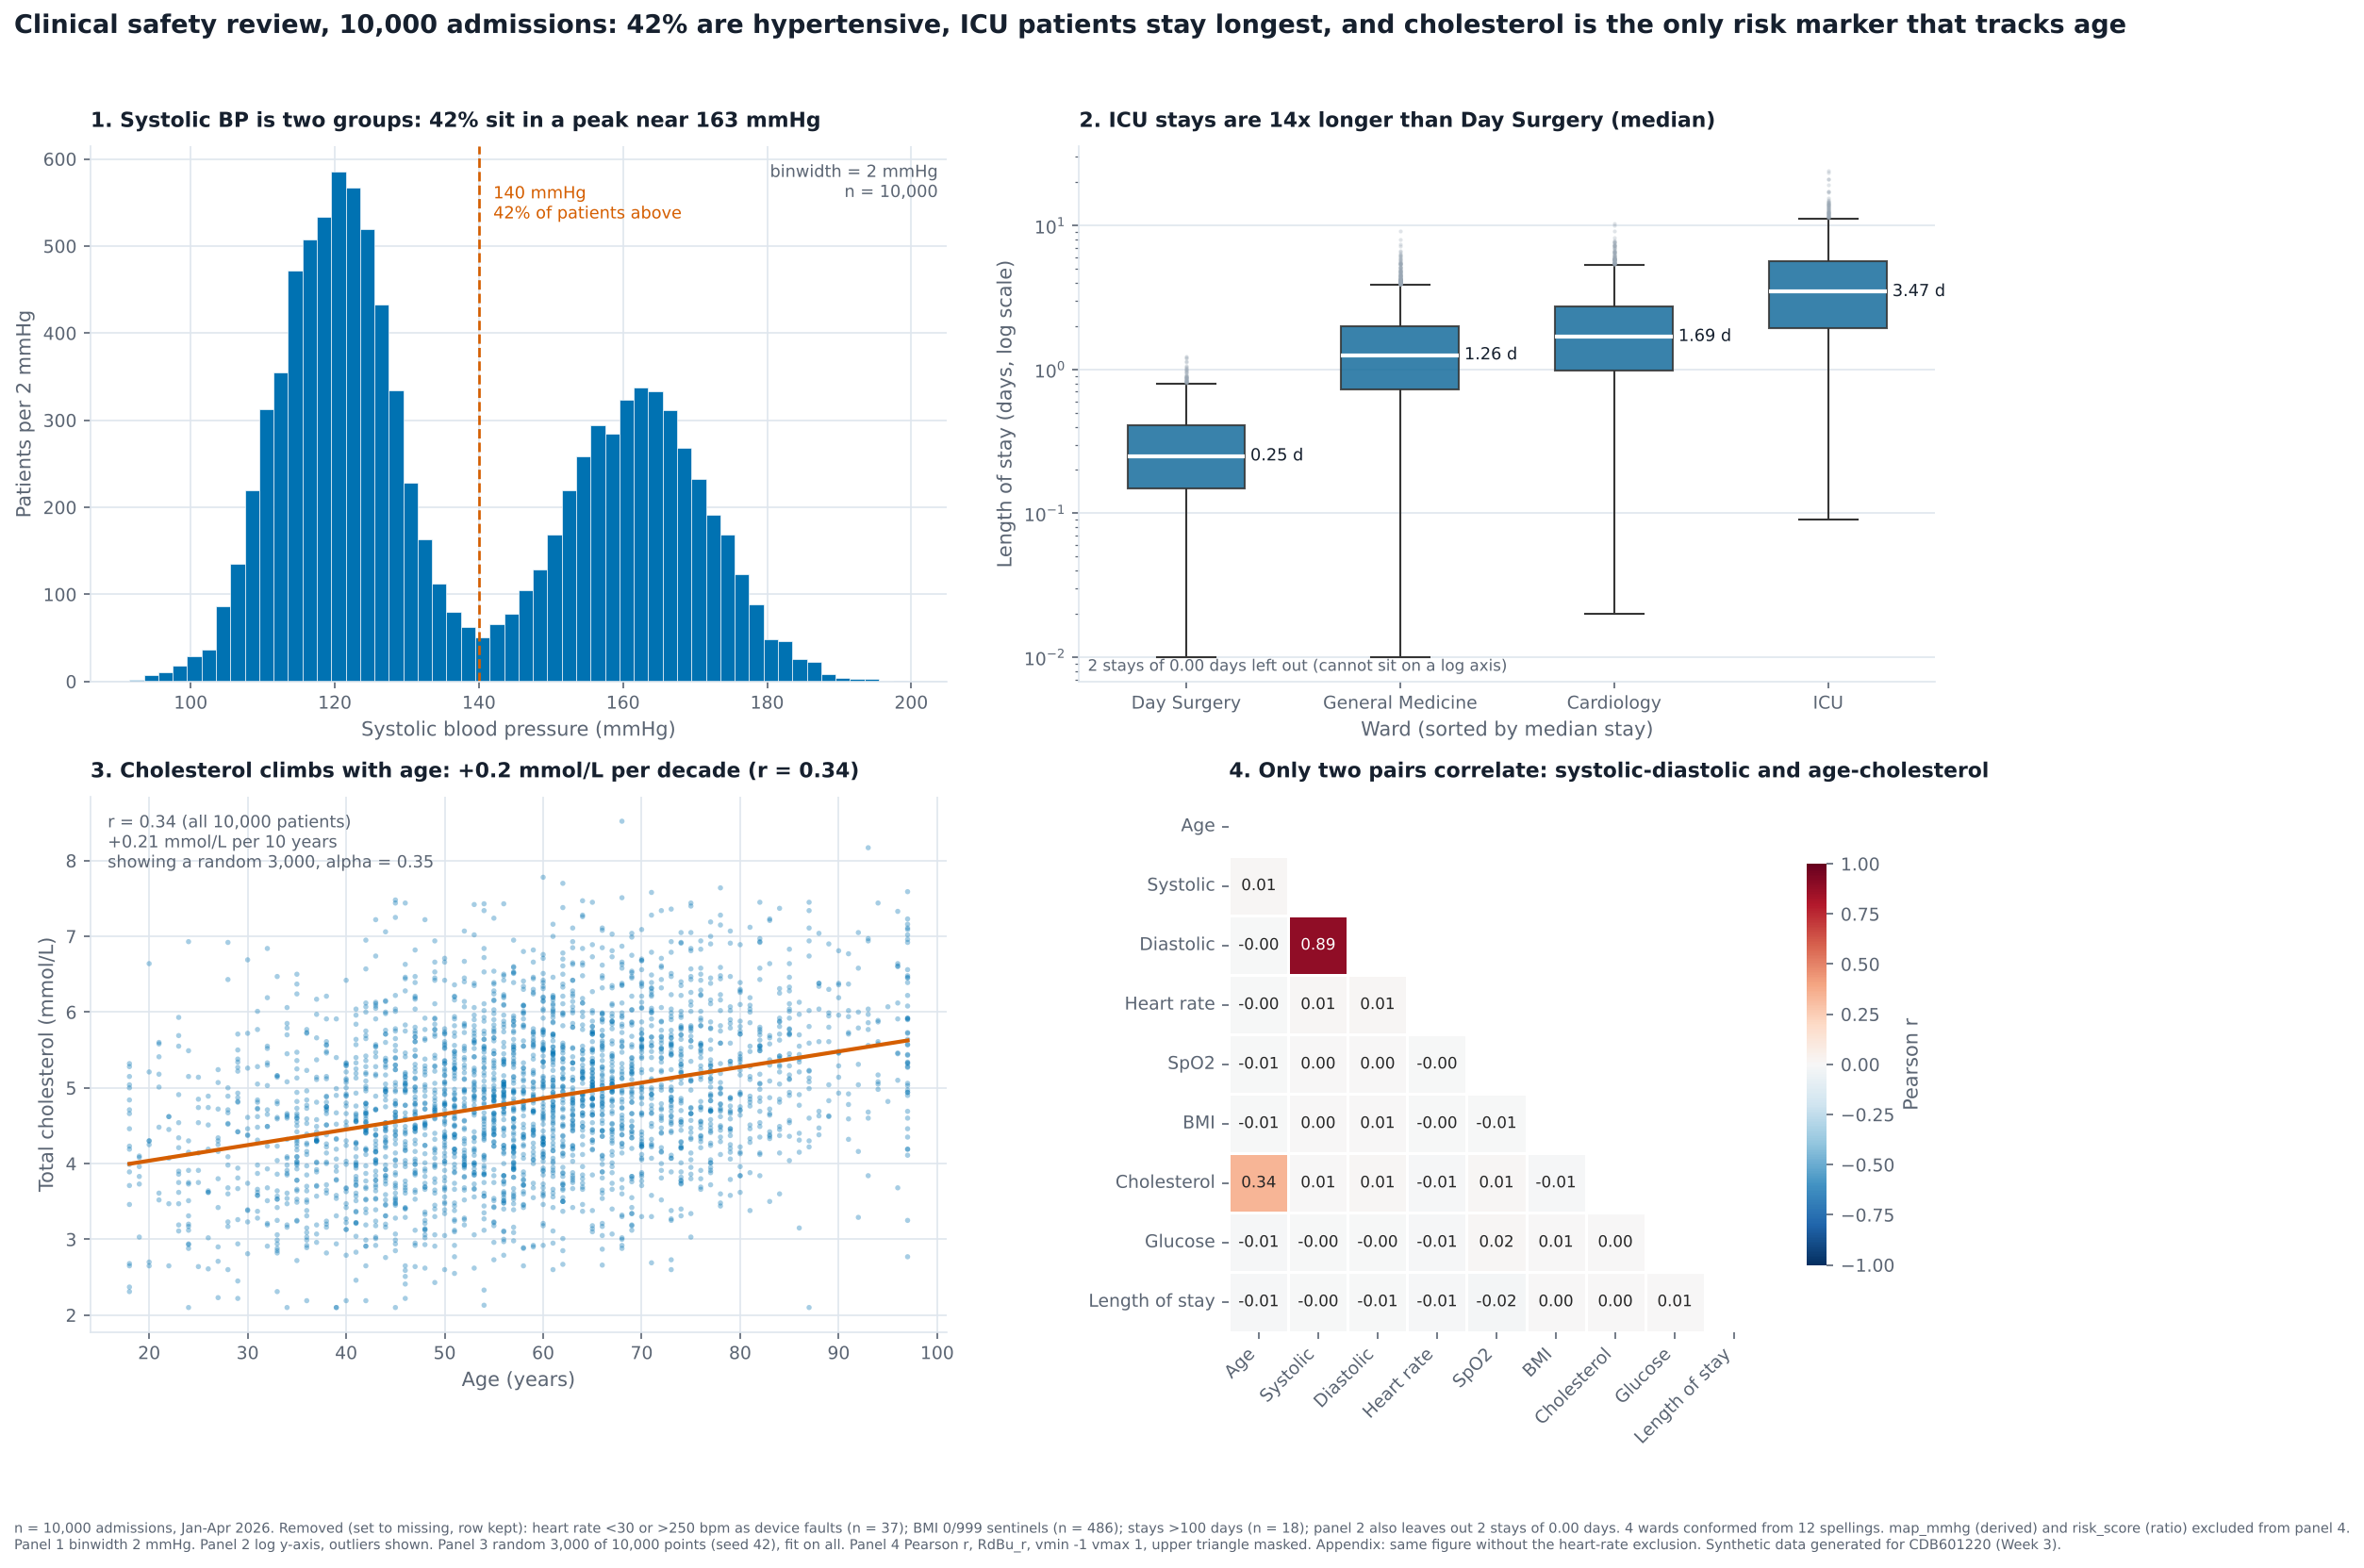

saved -> submission/partD_figure.png


'/home/claude/week3/submission/partD_figure.png'

In [15]:
n_hr = hr_fault.sum()
NOTE = (f"n = 10,000 admissions, Jan-Apr 2026. Removed (set to missing, row kept): heart rate <30 or >250 bpm as device faults (n = {n_hr}); "
        f"BMI 0/999 sentinels (n = {sent.sum()}); stays >100 days (n = {long_.sum()}); panel 2 also leaves out {(df.los_days == 0).sum()} stays of 0.00 days. 4 wards conformed from 12 spellings. "
        f"map_mmhg (derived) and risk_score (ratio) excluded from panel 4.\n"
        f"Panel 1 binwidth {BINW} mmHg. Panel 2 log y-axis, outliers shown. Panel 3 random {SAMPLE_N:,} of {df[['age','chol_mmol_l']].dropna().shape[0]:,} "
        f"points (seed 42), fit on all. Panel 4 Pearson r, RdBu_r, vmin -1 vmax 1, upper triangle masked. Appendix: same figure without the heart-rate exclusion. "
        + SRC)

fig = build_figure(df)
finish(fig, "partD_figure", NOTE, folder=SUB)

**What this chart shows.** Systolic blood pressure has two clear groups, and 42% of patients are hypertensive. ICU patients stay about 14 times longer than Day Surgery patients. Cholesterol is the only thing that rises with age, while most other measures barely relate to each other.

### Appendix - the same figure without the heart-rate exclusion

This is the version the ethics clause asks for. Only panel 4 uses heart rate, so that is the only panel that can change.

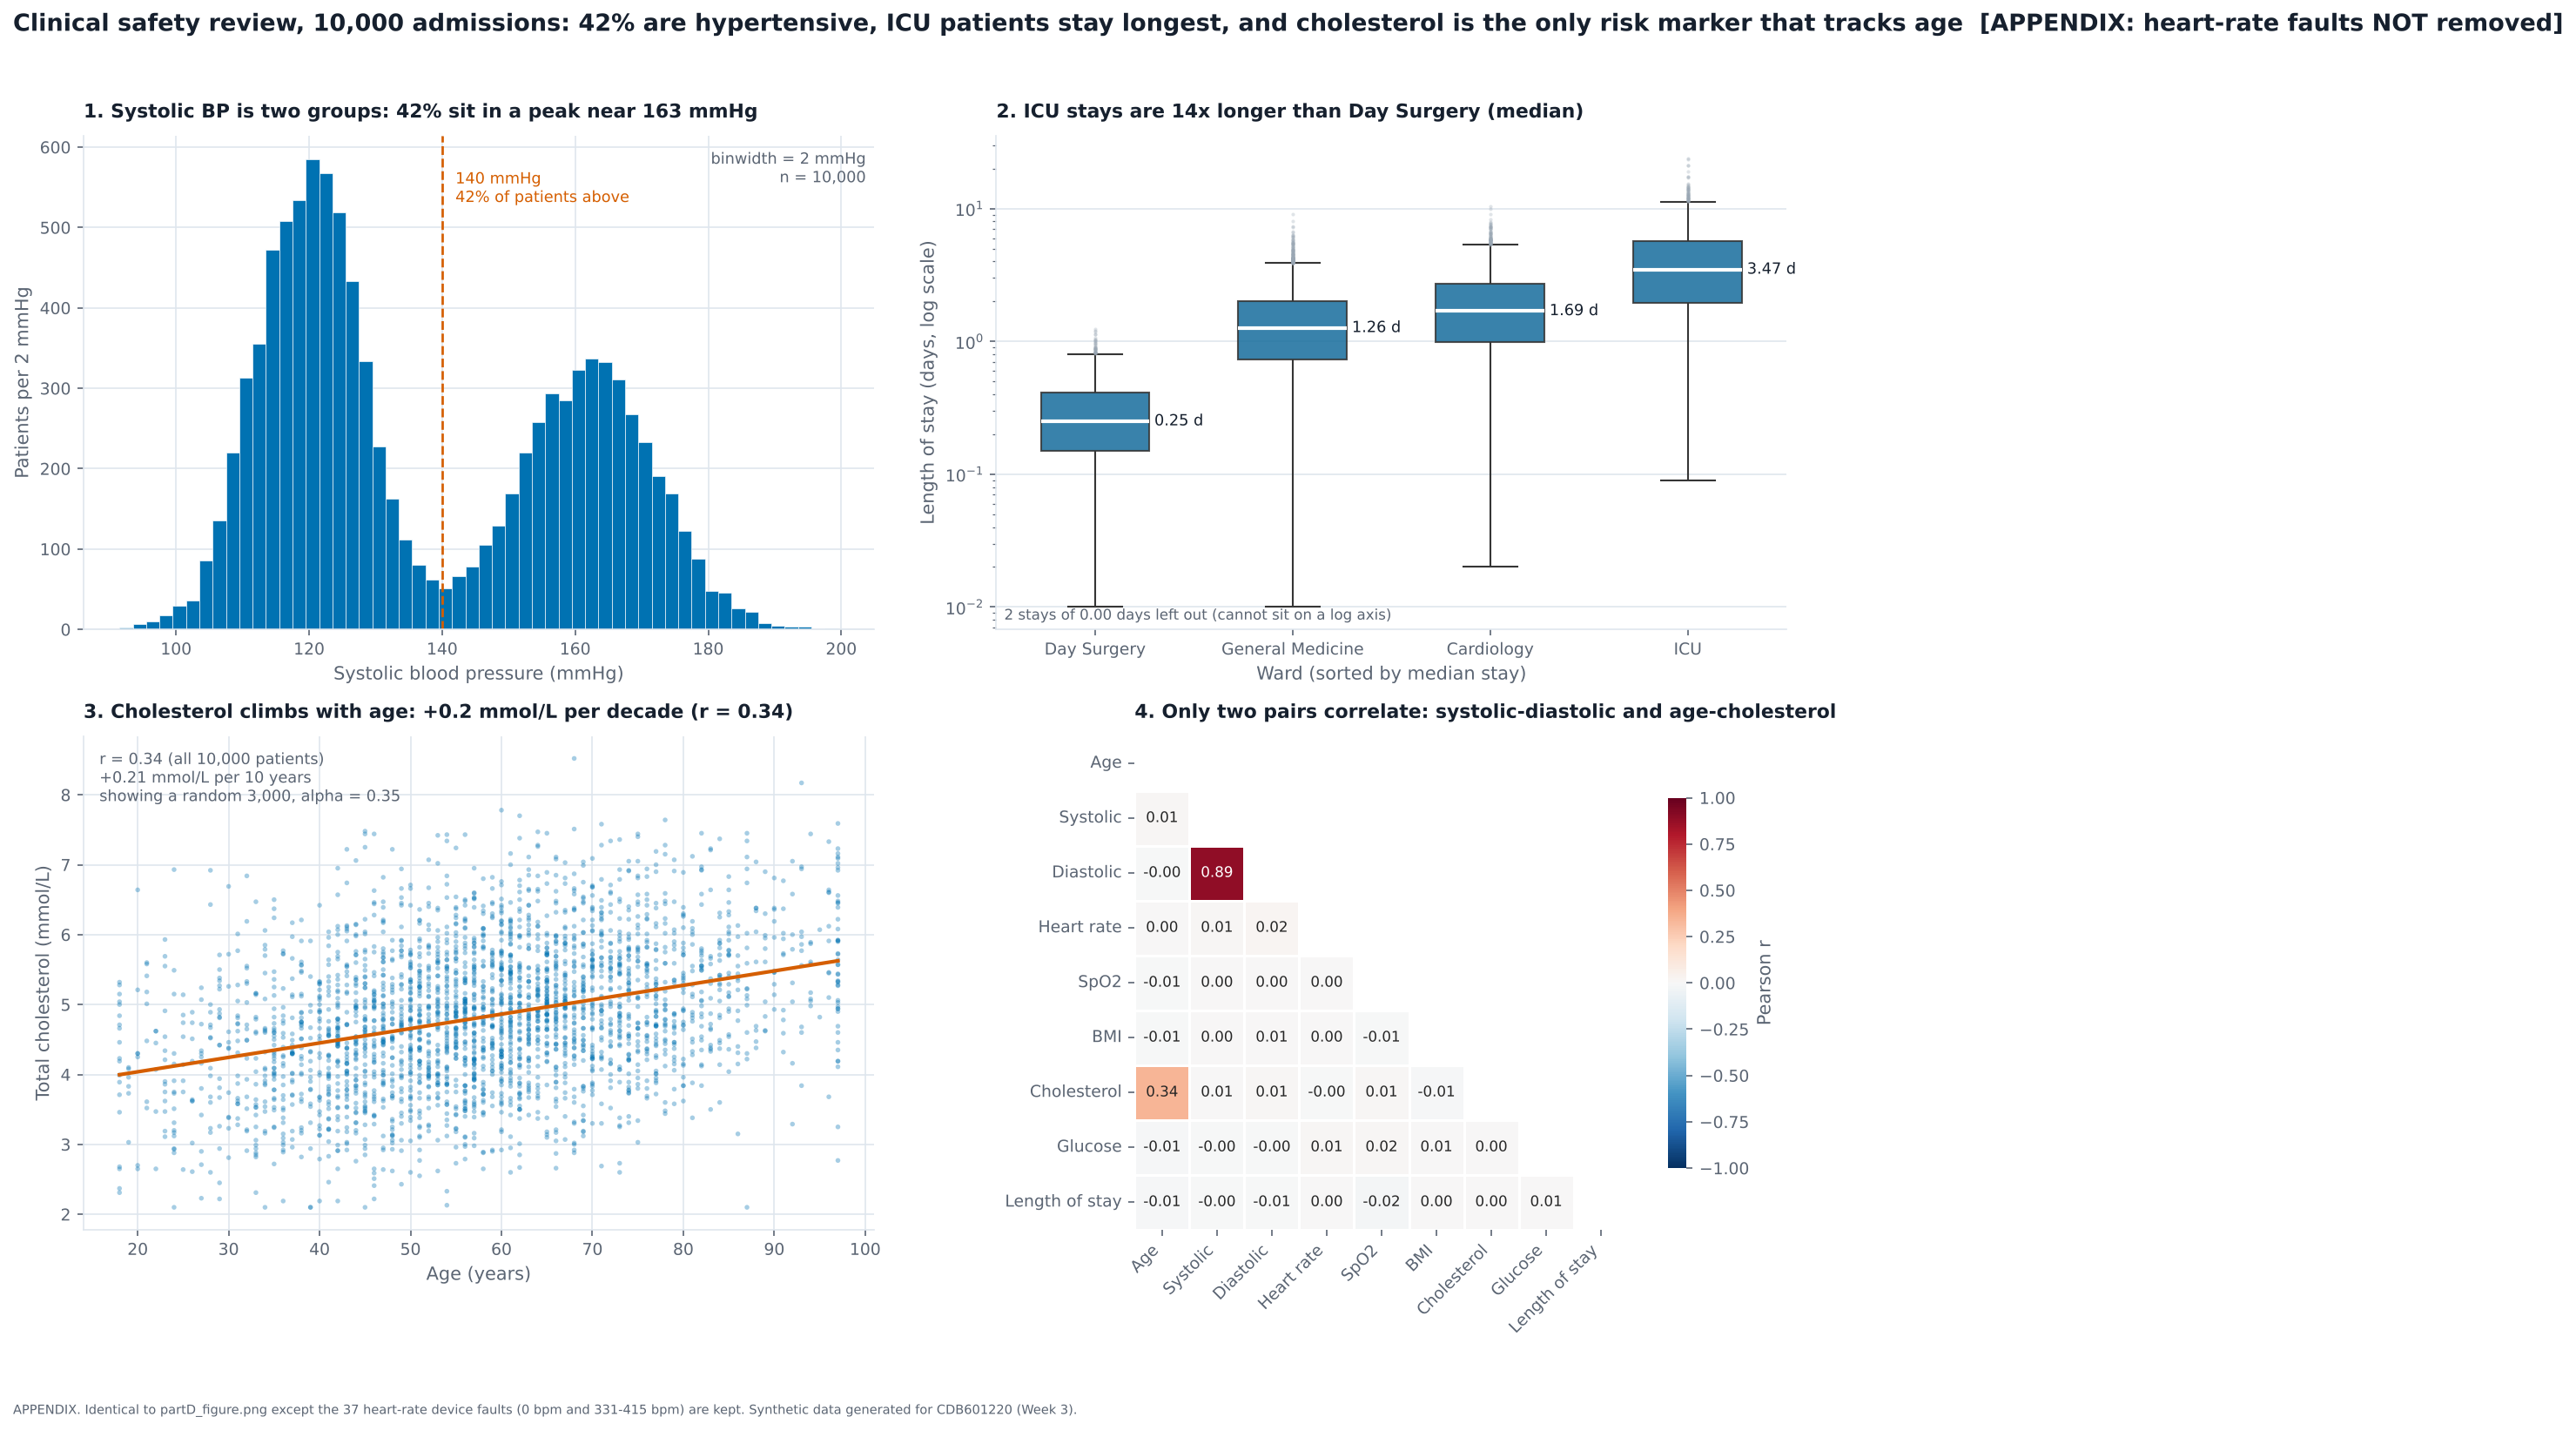

saved -> charts/partD_appendix_no_exclusion.png
largest change in any heart-rate correlation: 0.021


In [16]:
fig = build_figure(df, hr_col="heart_rate_raw", tag="  [APPENDIX: heart-rate faults NOT removed]")
finish(fig, "partD_appendix_no_exclusion",
       f"APPENDIX. Identical to partD_figure.png except the {n_hr} heart-rate device faults (0 bpm and 331-415 bpm) are kept. " + SRC)

hr_r_clean = df[HEAT_COLS].corr()["heart_rate"].drop("heart_rate")
hr_r_raw = df[[c if c != "heart_rate" else "heart_rate_raw" for c in HEAT_COLS]].corr()["heart_rate_raw"].drop("heart_rate_raw")
print("largest change in any heart-rate correlation:", (hr_r_clean.values - hr_r_raw.values).__abs__().max().round(3))

**What this chart shows.** This is the same figure with the 37 faulty heart-rate readings left in. Nothing important changes: no correlation moves by more than 0.03. So removing them was fair, and I'm not hiding anything that would change the results.

## Cleaning log (pasted into Part E)

In [17]:
for k, v in LOG.items():
    print(f"  {k:<34} {v}")
pd.Series(LOG).to_csv(SUB / "partD_cleaning_log.csv", header=["detail"])

  rows loaded                        10,000
  ward spellings conformed           12 spellings -> 4 wards (strip, lower, map); 0 rows lost
  dates parsed                       3 formats parsed separately (ISO 3382, dd-Mon 3365, dd/mm 3253); slash = day-first because 1933 have day > 12; 0 unparsed
  bmi sentinels removed              bmi == 0 (84) or 999 (402) -> NaN, n = 486; mean 66.18 -> 27.35 kg/m2
  heart-rate device faults removed   heart_rate < 30 (8, all 0 bpm) or > 250 (29, 331-415 bpm) -> NaN, n = 37; mean 78.83 -> 78.05 bpm
  implausible stays removed          los_days > 100 -> NaN, n = 18 (139.8-273.7 'days', likely hours keyed as days, incl. 6 in Day Surgery); mean 2.31 -> 1.95 days, median unchanged at 1.38
  derived column excluded            map_mmhg = (sys + 2 x dia)/3 -> left out of the heatmap (its r with sys/dia is arithmetic)
  ratio column not averaged          risk_score is events/day: mean of ratios 1.12 vs pooled rate 0.65 events/day -> not averaged, not in heatm